## Project 1 — Unsupervised Learning: EDA, k-Means, and PCA

## Part 0 — Finding and Choosing Your Dataset

When it came to finding datasets I had no candidates, I knew from the day that the project was introduced which dataset I wanted to use. I choose the Statbotics EPA dataset because I am a a alumni of the FRC program and I had already worked with the data on a shallow level. Choosing this dataset allowed me to work with it on a deeper level. The dataset comes from Statbotics, a well-known analytics website in the FRC community. Statbotics aggregates match results from FIRST events and applies there model to find the EPA(Expected Points Added) for every team every season. This data is always being updated as teams play events. When it comes to reliability, Statbotics is not a government agency or a established organization, it was started by another alumni of the program. However, Statbotics has established themselves as a reputable and trustworthy source in the FRC community. Many of their metrics are used by teams and scouting/strategy teams on each team (I was the strategy lead on my team which is why I am so familiar with it!). Grouping these observations into clusters is a meaningful thing to do because it can show various performance "traits" such as teams that have a strong auto performance, teams that score a ton in the tele-op phase, who is focused on the endgame etc. The question I am testing is how FRC teams group by naturally based on their performance estimated by the Statbotics EPA model. People that would care about these results are scouts, strategist, team analysts, mentors and anyone overall who cares about FRC robots. 

## Part 1 — Load, Inspect, and Clean

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("2026_insights (4-22).csv")  

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

# Detect the correct winrate column (anything containing "winrate")
winrate_col = None
for col in df.columns:
    if "winrate" in col.lower():
        winrate_col = col
        break

if winrate_col is None:
    raise ValueError("No winrate column found — check your CSV.")

print("Detected winrate column:", winrate_col)

numeric_cols = [
    "epa_rank", "total_epa", "norm_epa", "unitless_epa",
    "auto_epa", "teleop_epa", "endgame_epa",
    "rp_1_epa", "rp_2_epa", "rp_3_epa", winrate_col
]

# Filter to existing columns only
numeric_cols = [c for c in numeric_cols if c in df.columns]

print("Using numeric columns:", numeric_cols)

X = df[numeric_cols].dropna().to_numpy()
print("Shape of X:", X.shape)


Shape: (3724, 17)
Columns: ['num', 'team', 'epa_rank', 'total_epa', 'norm_epa', 'unitless_epa', 'auto_epa', 'teleop_epa', 'endgame_epa', 'rp_1_epa', 'rp_2_epa', 'rp_3_epa', 'next_event_key', 'next_event_name', 'next_event_week', 'record', 'winrate']
Detected winrate column: winrate
Using numeric columns: ['epa_rank', 'total_epa', 'norm_epa', 'unitless_epa', 'auto_epa', 'teleop_epa', 'endgame_epa', 'rp_1_epa', 'rp_2_epa', 'rp_3_epa', 'winrate']
Shape of X: (3724, 11)


Each row in the dataset is a single FRC team's performance summary for the season. For example, epa_rank is where you rank in the world, and epa_rank of 1 means that team is the number 1 team in the world. total_epa is how many points you contribute in each match which is than broken down into the phases of the game, auto_epa, teleop_epa and endgame_epa which then added back together gives you the total_epa. rp_1_epa, rp_2_epa, and rp_3_epa is how many points the team contributes towards getting the rp(ranking point). Winrate is a fraction of how many matches you won and lost. Only the numeric performance features were used in X. Identifier fields such as the team name or next_event_key/name were dropped because those columns were not numeric fields. 

## Part 2 — Exploratory Data Analysis

#### 2.1 Column Statistics

In [3]:
stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "std": df[numeric_cols].std(),
    "norm": np.sqrt((df[numeric_cols]**2).sum())
})

print("\nColumn Statistics:")
display(stats)



Column Statistics:


,mean,std,norm
epa_rank,1862.500000,1075.170529,131232.480164
total_epa,53.844495,48.113889,4406.276926
norm_epa,1502.632116,96.151888,91884.991299
unitless_epa,1526.199517,128.258275,93463.903444
auto_epa,11.562513,9.563799,915.640093
teleop_epa,28.436708,28.323116,2449.078486
endgame_epa,13.854726,11.812958,1111.019478
rp_1_epa,0.185585,0.212990,17.238196
rp_2_epa,-0.155422,0.153238,13.318390
rp_3_epa,-0.337556,0.018115,20.628873


Looking through the column statistics, it shows me that several features are present on dramatically different scales, the epa_rank, norm_epa, and unitless_epa have norms above 90,000 whereas the rp_(1-3)_epa and winrate have norms below 30. This suggests that in the raw feature space, the large norms such as total_epa with norm of 4406 and teleop_epa with norm of 2449 would dominate when it came to calculating the Euclidean distances. The smaller features such as the rp_EPAs and winrate would have almost zero contribution to clustering. This outcomes means that standardizing the data is important before applying the k-means algorithm. 

#### 2.2 Scatterplots

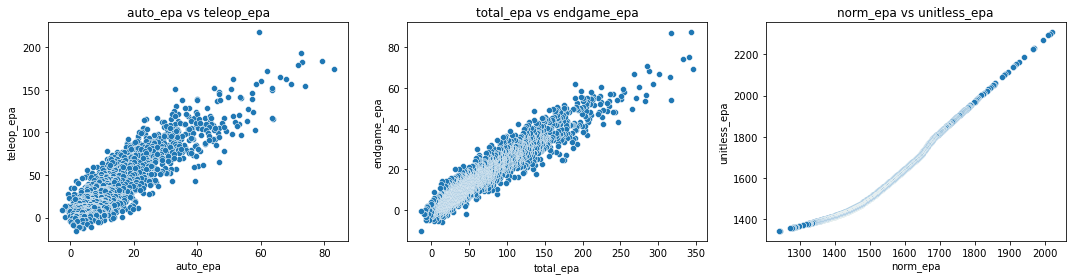

In [4]:
pairs = [
    ("auto_epa", "teleop_epa"),
    ("total_epa", "endgame_epa"),
    ("norm_epa", "unitless_epa")
]

plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(pairs):
    if x in df.columns and y in df.columns:
        plt.subplot(1, 3, i+1)
        sns.scatterplot(data=df, x=x, y=y)
        plt.title(f"{x} vs {y}")
plt.tight_layout()
plt.show()


I selected the following feature pairs: auto_epa and teleop_epa, total_epa and endgame_epa, and norm_epa and unitless_epa.
I choose the auto-teleop because I wanted to compare the two most important parts of a qualification round, and the scatterplot showed a strong, positive correlation which signaled to me that teams with a a good auto_epa also had a good teleop_epa. I choose total-endgame because I wanted to comapre a component metric to a overall aggregate but it showed a scatterplot with a strong, positive correlation which meant that the endgame phase mattered but it varied  more across teams. Finally, I choose norm-unitless because I wanted to check for redundancy between the EPA features and the scatterplot reavealed a tight, nonlinear curve that basically made me realize that norm_epa and unitless_epa are essentially the same. 

#### 2.2 Histograms

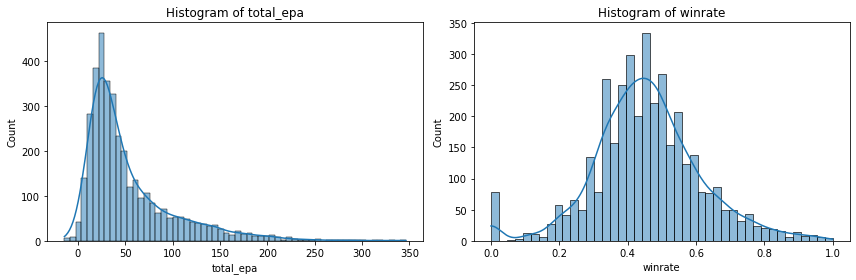

In [5]:
hist_vars = ["total_epa", winrate_col]

plt.figure(figsize=(12, 4))
for i, col in enumerate(hist_vars):
    if col in df.columns:
        plt.subplot(1, 2, i+1)
        sns.histplot(df[col], kde=True)
        plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()


I ended up choosing the total_epa and winrate variables for my histogram since the norm and unitless EPAs didn't provide much. The histogram for total_epa is very heavily skewed right, most teams ended up clustering around "average" EPA values with a "tail" going almost all the way up to 350 which are the best of the best/elite level teams. The winrate histogram clustered around and between 0.4 and 0.6 with teams that re closer to 1 having a higher winrate. Before seeing the histogram for winrate, I thought it would be slightly skewed right but I was surprised that it almost followed the normal distribution model. 

## Part 3 — Standardization

In [6]:
scaler = StandardScaler()
X_std = scaler.fit_transform(df[numeric_cols].dropna())

std_norms = np.sqrt((X_std**2).sum(axis=0))
norm_table = pd.DataFrame({"norm": std_norms}, index=numeric_cols)

print("\nNorms after standardization:")
display(norm_table)



Norms after standardization:


,norm
epa_rank,61.024585
total_epa,61.024585
norm_epa,61.024585
unitless_epa,61.024585
auto_epa,61.024585
teleop_epa,61.024585
endgame_epa,61.024585
rp_1_epa,61.024585
rp_2_epa,61.024585
rp_3_epa,61.024585


Standardizing the data was necessary for this dataset because the dataset has features that are scaled very differently. Scuch as epa_rank, norm_epa, and unitless_epa who have norms in the tens of thousands were as rp_(1-3)_epa and winrate have norms below 30. Even the medium size variables such as total_epa(norm = 4406) and teleop_epa(norm = 2449) would still dominate in the Euclidean distance calculation. Without standardizing the data, k-means would cluster all the teams based on the large EPA metric and not the rp_EPAs or winrate. Standardizing it allowed all features to contribute proportionally (the norm being 61.025) to the Euclidean distance, which allowed k-means to find clusters based on the patterns rather than the numerical scale.  

## Part 4 — The k-Means Objective Function and Algorithm

#### 4.1 The Objective Function


$$J^{\text{clust}} = \frac{1}{n} \sum_{i=1}^{n} \|\mathbf{x}_i - \mathbf{c}_{g_i}\|^2$$


In the context of my dataset
𝑥 is a single team’s standardized performance vector which includes the EPA metric and winrate

𝐶g𝑖 cluster 𝑖 is the group of teams that are similar in performance. For example, strong performance in auto, teleop, endgame etc. 

x𝑖 -the centroid of cluster 𝐶𝑖 represents the average EPA of teams in that cluster.

∥𝑥−cg𝑖∥^2 is the squared Euclidean distance between a team adn the centroid of the cluster that team belongs to.
The algorithm is trying to mimimize J^clust by trying to reduce the total squared distance between every point(the team) and the centroid of the cluster each team belongs to.  



##### 4.2 Lloyd's Algorithm in Your Own Words


Lloyd's algorithm starts by initializing the centroids by selecting k starting points, then Scikit-learn uses k-means++ to choose a initial centroids. Step 2, for every team, it will calculate the distance to each centroid and assign each team to the closest one, this is done by using Scikit-learn and specifically, fit_predictor() and X_std. Step 3, it will recalculate each centroid as the mean of all teams that were assigned to that cluster and this is done by the python line .fit(). Step 4, it will repeat by alternating between assigning and updated the centroids until it doesn't change significantly. Last step, it will converge; the final centroids represents the main features of the dataset. 

## Part 5 — k-Means with Scikit-learn

#### 5.1 Elbow Plot

In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_std)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Plot")
plt.show()


I ran the k-means on the standardized data X_std for k from 1 to 10 and plotted the inertia, which is the sum of squared distances to centroids as a function of k. As inertia decreased, k increased but the rate of decrease will slow down after a certain point. My elbow plot "elbowed" between the k values of 2 and 3, it then flattened out after 3. I decdied to chose k equals 3 since it looked to me where it "elbowed" the most since it looked reasonable and it would capture more rather than a 2 cluster split which essentially mean that teams are either good or bad and no in-between. 

#### 5.2 Final Model

In [ ]:
k_final = 3

kmeans = KMeans(n_clusters=k_final, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_std)

print("\nCluster counts:")
print(pd.Series(labels).value_counts())

print("\nCluster centroids (standardized):")
display(pd.DataFrame(kmeans.cluster_centers_, columns=numeric_cols))


After selecting k = 3, it produced three clusters varying in size of how many teams were in each cluster. Cluster 0 contained 2322 teams, Cluster 1 had 1043 and Cluster 2 had 359. To me, this distribution suggests that a large group of teams are average or below-average teams with a small group being in the best of best teams. The standardized centroids backed this up, cluster 0 had negative values across all the EPA metrics and winrate which indicated that teams in cluster 0 performed below the dataset mean in every aspect of a match. Cluster 1 had negative values but had more positives instead which meant the teams in cluster 1 were essential "mid" tier teams. Cluster 2 stands out because it's centroid has a very large positive values across all EPA metrics which showed that teams in cluster 2 were the best of the best teams. 

## Part 6 — PCA and Visualization

#### 6.1 PCA — Variance Explained

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("\nExplained variance PC1:", pca.explained_variance_ratio_[0])
print("Explained variance PC2:", pca.explained_variance_ratio_[1])
print("Total explained:", pca.explained_variance_ratio_.sum())


PC1 captured about 77% of the total variance. PC2 captured a additional 9%, which brings the total to 86%. This is pretty high which means that the PCA projection captured a majority of the data. However, the the left over 14% means that there were some distinctions between teams that exist in the higher dimensions that, of course, can't be plotted on a 2 dimensional graph. 

#### 6.2 Visualization

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, ax=ax[0], palette="tab10")
ax[0].set_title("PCA — Colored by K-Means Cluster")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df[winrate_col], ax=ax[1], palette="viridis")
ax[1].set_title("PCA — Colored by Winrate")

# Detect team identifier column
team_col = None
for col in df.columns:
    if col.lower() in ["team", "num", "team_number", "team_num"]:
        team_col = col
        break

if team_col is None:
    raise ValueError("No team identifier column found.")

# Transform centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot centroids on both panels
for i in range(k_final):
    ax[0].scatter(
        centroids_pca[i, 0], centroids_pca[i, 1],
        s=200, c="black", marker="X", edgecolor="white", linewidth=2
    )
    ax[1].scatter(
        centroids_pca[i, 0], centroids_pca[i, 1],
        s=200, c="black", marker="X", edgecolor="white", linewidth=2
    )

plt.show()


The PCA projection, to me, suggests that the three clusters are partially separated. There is a clear distinction of a left-to-right structure in PC1 but not well separated in PC2. In the left panel, the blue cluster is concentrated in the far left side, the orange cluster essentially occupies the middle and the green dominates the entire right side. The right panel is not well separated, though the lower winrates appear on the left side as it should, the higher winrates are bit more of a mess. This indicates that PC1 is associated with winrate because the color transition follows the cluster transitions. Where k-means and ground-truth labels agree is the far left of both panels, where the blue cluster is in agreement with low winrates and far right of the panels, where the green cluster is in agreement with high winrates. The disagreement is mostly in the middle where PC1 appox 0-3, wherethe orange and blue data points overlap while the winrates vary continously rather than discretely. The second disagreement is where PC1 appox 3-6, where the orange and green clusters overlap desite the similar medium to high winrates.  

## Part 7 — Reflection

Doing this analysis provided several insights that I don't think I would have noticed from the raw data file. The cluster centroids showed exactly what separated a elite, mid and underperforming teams. The skewed distribution of total_epa and the somewhat normal distribution of winrate explained why the best teams cluster was small adn why "mid" teams were dominant in the dataset. Clustering the results showed if teams were similar performance wise but didn't account for teams that could have similar winrates but different epa performances and vice versa since the match schedule is randomly generated. In my opinion, there were some limitations, the choice of k = 3 though reasonable because of the elbow plot, I felt that potentially choosing a different k value could have revealed more subgroups. Additionally, the PCA visualization captured only a part of the variance so some clusters could be more clearer in higher dimensions. Finally, the biggest limitation is that EPA is a model-based metric so the clusters include both performance and model assumptions. Something I could explore in the future is waiting for all events to finish, when I was working on this project, the world championship was happening, which means that every team's EPA was either increasing, decreasing or staying the same in real time. This made the results that were presented throughtout this project outdated. 